# Lecture 02: Symplectic Form on the Cotangent Bundle

**Source span.** Printed pages 7-12; physical PDF pages 21-26 in `Lectures on Symplectic Geometry.pdf` according to the course source map. I checked the local PDF text for the cotangent-bundle lecture before revising this notebook.

**Lecture goal.** Construct the first large family of symplectic manifolds: every cotangent bundle `T^*X` carries a canonical symplectic form. The key object is the tautological one-form `alpha`, defined so that a covector sitting over `x` evaluates tangent vectors after projection back to `X`; the canonical two-form is `omega=-d alpha`.

The lecture is a model for a recurring theme in symplectic geometry: a formula first appears in coordinates, then an intrinsic definition explains why the formula survives changes of chart. Here the local formula `alpha=sum xi_i dx_i` is not a coordinate accident. It is the coordinate shadow of the projection `pi:T^*X -> X` and the covector carried by each point of the cotangent bundle.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate
    raise RuntimeError("Could not locate the Lectures-on-Symplectic-Geometry course root.")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, read_json, save_json, save_matplotlib

ARTIFACT_TOPIC = "lecture-02"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / ARTIFACT_TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CHECK_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: D:\Geometry\Lectures-on-Symplectic-Geometry
Artifact root: artifacts\lecture-02


## Translation Guide

| Source idea | Computational object | What to inspect |
| --- | --- | --- |
| Cotangent coordinates | base coordinates `x_i` plus fiber coefficients `xi_i` | a covector changes by the inverse-transpose Jacobian rule |
| Tautological one-form | `alpha=sum xi_i dx_i` or `alpha_p(v)=xi(d pi_p v)` | the same value is obtained from coordinates and from projection |
| Canonical symplectic form | `omega=-d alpha=sum dx_i wedge dxi_i` | its matrix is nondegenerate and closed because it is exact |
| Coordinate independence | pull back `alpha` through a chart change | the coefficient of `dx` is unchanged after substituting `x'=f(x)` and `xi'=xi/f'(x)` |
| Naturality | cotangent lift `f#` of a base diffeomorphism | `f#* alpha_2=alpha_1` and therefore `f#* omega_2=omega_1` |
| `T^*S^1` example | cylinder coordinates `(theta, xi)` | lifted circle diffeomorphisms preserve the cylinder area form |
| Fiber translation warning | `(theta, xi)->(theta, xi+c)` | it preserves `omega` but is not a cotangent lift from a base diffeomorphism |
| Symplectic volume homework | top exterior power `omega^n` | nonzero top wedge means orientation and volume; compact exact symplectic forms are obstructed |

## Library Routing

This lecture uses `sympy` for exact pullback identities, because the point of the chapter is coordinate independence rather than numerical approximation. `numpy` checks nondegeneracy and finite residuals, `matplotlib` draws cotangent fibers, lifted cylinder grids, and volume ledgers, and `networkx` records the proof dependencies. The notebook avoids a heavy differential-geometry package because the core formulas are transparent in low-dimensional coordinates.

## Visual Storyboard

The visual sequence follows the lecture order.

1. **Cotangent coordinates and `alpha`.** A base chart, vertical cotangent fibers, and the projection diagram show why a point `(x,xi)` in `T^*X` carries a covector ready to evaluate projected tangent vectors.
2. **Naturality under a cotangent lift.** A diffeomorphism of the base bends the coordinate grid on `T^*S^1`, but the area coefficient of `dtheta wedge dxi` remains one.
3. **Canonical proof route.** The diagram separates the coordinate formula, coordinate-free definition, exactness, nondegeneracy, and naturality theorem.
4. **Symplectic volume ledger.** The homework theme is represented by determinant/top-wedge checks: nonzero `omega^n` is the volume witness.

Every artifact is regenerated by the code cells in this notebook and saved under `artifacts/lecture-02/`.

In [2]:
# Visual 1: the tautological form evaluates a covector after projection to the base.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
ax.set_title("Cotangent coordinates: base point plus covector fiber")
base_x = np.linspace(-2.5, 2.5, 200)
ax.plot(base_x, np.zeros_like(base_x), color="#1d3557", lw=2)
for x0, color in [(-1.5, "#8ecae6"), (0.0, "#90be6d"), (1.5, "#f9c74f")]:
    ax.plot([x0, x0], [-1.2, 1.2], color=color, lw=2)
    ax.scatter([x0], [0], s=80, color=color, edgecolor="black", zorder=3)
    ax.text(x0, -1.36, f"x={x0:g}", ha="center")
ax.scatter([0.0], [0.75], s=120, color="#e76f51", edgecolor="black", zorder=4)
ax.annotate("p=(x, xi) in T^*X", xy=(0, 0.75), xytext=(0.55, 1.18), arrowprops={"arrowstyle": "->"})
ax.arrow(0, 0.75, 0.65, 0.0, head_width=0.07, color="#e76f51", length_includes_head=True)
ax.text(0.72, 0.75, "vertical fiber coordinate xi", va="center")
ax.arrow(0, 0.75, 0, -0.62, head_width=0.07, color="#495057", length_includes_head=True)
ax.text(-0.08, 0.32, "pi", ha="right")
ax.text(0.1, -0.12, "x", va="top")
ax.set_xlim(-2.8, 2.8)
ax.set_ylim(-1.55, 1.45)
ax.set_xlabel("base coordinate")
ax.set_ylabel("cotangent fiber")
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
ax.set_title("Coordinate-free definition of alpha")
ax.axis("off")
boxes = {
    "p=(x,xi)": (0.1, 0.75),
    "v in T_p(T^*X)": (0.1, 0.35),
    "d pi_p(v) in T_xX": (0.58, 0.35),
    "xi(d pi_p v)": (0.58, 0.75),
}
for text, (x0, y0) in boxes.items():
    ax.text(x0, y0, text, ha="center", va="center", bbox={"boxstyle": "round,pad=0.35", "fc": "#f4f7fb", "ec": "#355070"})
ax.annotate("projection", xy=boxes["d pi_p(v) in T_xX"], xytext=boxes["v in T_p(T^*X)"], arrowprops={"arrowstyle": "->", "lw": 1.8})
ax.annotate("covector evaluates", xy=boxes["xi(d pi_p v)"], xytext=boxes["d pi_p(v) in T_xX"], arrowprops={"arrowstyle": "->", "lw": 1.8})
ax.annotate("alpha_p(v)", xy=boxes["xi(d pi_p v)"], xytext=boxes["p=(x,xi)"], arrowprops={"arrowstyle": "->", "lw": 1.8})
ax.text(0.34, 0.08, "In coordinates this is alpha = sum xi_i dx_i.", ha="center", fontsize=10)

cotangent_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "cotangent-coordinates-tautological-form.png")
plt.close(fig)
print(cotangent_path.relative_to(BOOK_ROOT))
assert cotangent_path.exists()

artifacts\lecture-02\figures\cotangent-coordinates-tautological-form.png


In [3]:
# Visual 2: a cotangent lift preserves the canonical area form on T^*S^1.
theta = np.linspace(0, 2*np.pi, 240)
a = 0.32
fprime = 1 + a * np.cos(theta)
Ftheta = theta + a * np.sin(theta)
xi_levels = np.linspace(-1.5, 1.5, 7)
theta_lines = np.linspace(0, 2*np.pi, 9)[:-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
axes[0].set_title("source cylinder coordinates")
for x0 in theta_lines:
    axes[0].plot([x0, x0], [-1.7, 1.7], color="#b8c0c8", lw=0.9)
for eta0 in xi_levels:
    axes[0].plot(theta, np.full_like(theta, eta0), color="#8ecae6", lw=1.1)
axes[0].set_xlabel("theta")
axes[0].set_ylabel("xi")
axes[0].set_xlim(0, 2*np.pi)
axes[0].set_ylim(-1.8, 1.8)

axes[1].set_title("after cotangent lift: (Q, Eta)=(f(theta), xi/f'(theta))")
for x0 in theta_lines:
    fp = 1 + a * np.cos(x0)
    q0 = x0 + a * np.sin(x0)
    axes[1].plot([q0, q0], [-1.7/fp, 1.7/fp], color="#b8c0c8", lw=0.9)
for eta0 in xi_levels:
    axes[1].plot(Ftheta, eta0 / fprime, color="#8ecae6", lw=1.1)
axes[1].set_xlabel("Q=f(theta)")
axes[1].set_xlim(0, 2*np.pi)
axes[1].text(0.05, 0.92, "Pullback coefficient of dQ wedge dEta is 1", transform=axes[1].transAxes, bbox={"boxstyle": "round,pad=0.3", "fc": "#e8f3ee", "ec": "#4d908e"})
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

lift_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "cotangent-lift-naturality-cylinder.png")
plt.close(fig)
print(lift_path.relative_to(BOOK_ROOT))
assert np.min(fprime) > 0

artifacts\lecture-02\figures\cotangent-lift-naturality-cylinder.png


In [4]:
# Visual 3: proof dependencies for the canonical form.
G = nx.DiGraph()
edges = [
    ("cotangent coordinates", "alpha=sum xi_i dx_i"),
    ("projection pi", "alpha_p(v)=xi(d pi_p v)"),
    ("alpha_p(v)=xi(d pi_p v)", "coordinate independence"),
    ("coordinate independence", "omega=-d alpha"),
    ("alpha=sum xi_i dx_i", "omega=-d alpha"),
    ("omega=-d alpha", "closed because exact"),
    ("omega=-d alpha", "nondegenerate matrix"),
    ("closed because exact", "canonical symplectic form"),
    ("nondegenerate matrix", "canonical symplectic form"),
    ("base diffeomorphism f", "cotangent lift f#"),
    ("cotangent lift f#", "f#* alpha_2=alpha_1"),
    ("f#* alpha_2=alpha_1", "f#* omega_2=omega_1"),
    ("canonical symplectic form", "T^*S^1 cylinder example"),
    ("fiber translation", "symplectic but not base lift"),
]
G.add_edges_from(edges)
pos = {
    "cotangent coordinates": (0, 1.1),
    "alpha=sum xi_i dx_i": (1.8, 1.1),
    "projection pi": (0, -0.25),
    "alpha_p(v)=xi(d pi_p v)": (1.8, -0.25),
    "coordinate independence": (3.7, 0.35),
    "omega=-d alpha": (3.7, 1.1),
    "closed because exact": (5.4, 1.65),
    "nondegenerate matrix": (5.4, 0.6),
    "canonical symplectic form": (7.3, 1.1),
    "base diffeomorphism f": (3.7, -1.15),
    "cotangent lift f#": (5.4, -1.15),
    "f#* alpha_2=alpha_1": (7.3, -1.15),
    "f#* omega_2=omega_1": (9.2, -1.15),
    "T^*S^1 cylinder example": (9.2, 1.1),
    "fiber translation": (7.3, 2.1),
    "symplectic but not base lift": (9.2, 2.1),
}
fig, ax = plt.subplots(figsize=(12.5, 5.2))
colors = []
for node in G.nodes:
    if "omega" in node or "symplectic" in node:
        colors.append("#90be6d")
    elif "alpha" in node:
        colors.append("#8ecae6")
    else:
        colors.append("#f9c74f")
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.4, edge_color="#495057")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=1900, edgecolors="#1f2937")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_axis_off()
ax.set_title("Lecture 02 proof route: coordinate formula, intrinsic alpha, canonical omega, naturality")
route_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "cotangent-canonical-proof-route.png")
plt.close(fig)
print(route_path.relative_to(BOOK_ROOT))
assert nx.has_path(G, "projection pi", "canonical symplectic form")
assert nx.has_path(G, "base diffeomorphism f", "f#* omega_2=omega_1")

artifacts\lecture-02\figures\cotangent-canonical-proof-route.png


In [5]:
# Visual 4: symplectic volume and the nonzero top wedge witness.
def standard_omega_matrix(n):
    top = np.hstack([np.zeros((n, n)), np.eye(n)])
    bottom = np.hstack([-np.eye(n), np.zeros((n, n))])
    return np.vstack([top, bottom])

dimensions = [2, 4, 6]
determinants = [float(np.linalg.det(standard_omega_matrix(n // 2))) for n in dimensions]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), gridspec_kw={"width_ratios": [1, 1.25]})
axes[0].bar([str(d) for d in dimensions], determinants, color=["#8ecae6", "#90be6d", "#f9c74f"])
axes[0].set_title("Nonzero determinant witnesses nondegeneracy")
axes[0].set_xlabel("dimension 2n")
axes[0].set_ylabel("det(Omega_0)")
axes[0].set_ylim(0, 1.25)
for x_pos, value in enumerate(determinants):
    axes[0].text(x_pos, value + 0.04, f"{value:g}", ha="center")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].axis("off")
ledger = [
    ["omega^n nonzero", "volume form"],
    ["volume form", "canonical orientation"],
    ["compact + omega exact", "Stokes obstruction"],
    ["S^{2n}, n>1", "no symplectic form"],
]
table = axes[1].table(cellText=ledger, colLabels=["check", "consequence"], loc="center", cellLoc="center", colLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.7)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#244b5a")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#f4f7fb" if c == 0 else "#e8f3ee")
axes[1].set_title("Homework 2: top wedge and compactness consequences", pad=20)

volume_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "symplectic-volume-wedge-ledger.png")
plt.close(fig)
print(volume_path.relative_to(BOOK_ROOT))
assert all(abs(value) > 1e-12 for value in determinants)

artifacts\lecture-02\figures\symplectic-volume-wedge-ledger.png

In [6]:
# Exact pullback checks: coordinate changes and cotangent lifts preserve alpha and omega.
theta, xi, a_symbol = sp.symbols("theta xi a", real=True)
f = theta + a_symbol * sp.sin(theta)
fp = sp.diff(f, theta)
eta = xi / fp

alpha_pullback_coefficient = sp.simplify(eta * fp)
omega_pullback_coefficient = sp.simplify(sp.diff(f, theta) * sp.diff(eta, xi) - sp.diff(f, xi) * sp.diff(eta, theta))

# A section mu(q)=g(q)dq pulls alpha back to mu.
g = sp.Function("g")
section_alpha_coefficient = g(theta)

omega2 = np.array([[0.0, 1.0], [-1.0, 0.0]])
canonical_det = float(np.linalg.det(omega2))
translation_jacobian = np.array([[1.0, 0.0], [0.0, 1.0]])
fiber_translation_residual = float(np.linalg.norm(translation_jacobian.T @ omega2 @ translation_jacobian - omega2))

checks = {
    "lecture": 2,
    "tautological_form": {
        "coordinate_formula": "alpha=sum xi_i dx_i",
        "coordinate_free_formula": "alpha_p(v)=xi(d pi_p v)",
        "section_pullback_alpha_equals_mu": str(section_alpha_coefficient),
    },
    "cotangent_lift": {
        "base_map": "Q=theta+a sin(theta)",
        "fiber_map": "Eta=xi/(1+a cos(theta))",
        "alpha_pullback_coefficient": str(alpha_pullback_coefficient),
        "omega_pullback_coefficient": str(omega_pullback_coefficient),
        "alpha_invariant": bool(sp.simplify(alpha_pullback_coefficient - xi) == 0),
        "omega_invariant": bool(sp.simplify(omega_pullback_coefficient - 1) == 0),
    },
    "canonical_form": {
        "omega_matrix_determinant": canonical_det,
        "nondegenerate": bool(abs(canonical_det) > 1e-12),
        "closed_because_exact": True,
    },
    "fiber_translation": {
        "preserves_omega_residual": fiber_translation_residual,
        "comes_from_base_lift": False,
    },
    "volume_homework": {
        "standard_determinants": determinants,
        "top_wedge_nonzero": all(abs(value) > 1e-12 for value in determinants),
    },
}
checks["passed"] = bool(
    checks["cotangent_lift"]["alpha_invariant"]
    and checks["cotangent_lift"]["omega_invariant"]
    and checks["canonical_form"]["nondegenerate"]
    and checks["fiber_translation"]["preserves_omega_residual"] < 1e-12
    and checks["volume_homework"]["top_wedge_nonzero"]
)
check_path = save_json(checks, ARTIFACT_TOPIC, "checks", "cotangent-canonical-residuals.json")
print(check_path.relative_to(BOOK_ROOT))
assert checks["passed"]
assert sp.simplify(alpha_pullback_coefficient - xi) == 0
assert sp.simplify(omega_pullback_coefficient - 1) == 0
assert checks["fiber_translation"]["preserves_omega_residual"] < 1e-12

artifacts\lecture-02\checks\cotangent-canonical-residuals.json


## Reading The Visuals

The first figure is the coordinate-free definition in plain sight. A point of the cotangent bundle is already a covector `xi` over a base point `x`. Given a tangent vector upstairs, `d pi` throws away the vertical part and returns a tangent vector downstairs; the covector then evaluates it. In coordinates this becomes `alpha=sum xi_i dx_i`.

The cylinder figure is the naturality theorem as a computation. For a base map `Q=f(theta)`, the lifted fiber coordinate must be `Eta=xi/f'(theta)` so that `Eta dQ = xi dtheta`. Differentiating gives `dQ wedge dEta = dtheta wedge dxi`, which is why the cotangent lift is a symplectomorphism. A vertical translation of the fiber also preserves `omega`, but it does not arise from a base diffeomorphism; this explains the non-surjectivity warning in the lecture.

The volume ledger records the homework extension. Once `omega` is nondegenerate in dimension `2n`, the top exterior power is a nonzero volume form. On compact manifolds, this interacts with Stokes' theorem: an exact symplectic form would force the total top volume to vanish, so compact examples have cohomological restrictions.

In [7]:
source_span = {
    "lecture": 2,
    "label": "Lecture 02",
    "title": "Symplectic Form on the Cotangent Bundle",
    "printed_span": "7-12",
    "physical_pdf_span": "21-26",
    "source_checked": True,
    "source_role": "Used for terminology, theorem order, examples, and homework themes; prose and visuals here are original.",
}
visual_storyboard = {
    "lecture": 2,
    "title": "Symplectic Form on the Cotangent Bundle",
    "source_span": source_span,
    "chapter_goal": "Make the tautological one-form, canonical two-form, naturality, and symplectic volume checks visible and executable.",
    "library_routing": [
        {"library": "sympy", "use": "exact pullback identities for alpha and omega"},
        {"library": "numpy", "use": "nondegeneracy and residual checks"},
        {"library": "matplotlib", "use": "cotangent fiber, cylinder lift, and volume diagrams"},
        {"library": "networkx", "use": "canonical-form proof route"},
    ],
    "visual_sequence": [
        {"concept": "cotangent coordinates and tautological one-form", "artifact": "artifacts/lecture-02/figures/cotangent-coordinates-tautological-form.png", "inspection_target": "alpha evaluates a covector after tangent projection"},
        {"concept": "naturality under cotangent lifts", "artifact": "artifacts/lecture-02/figures/cotangent-lift-naturality-cylinder.png", "inspection_target": "lifted base diffeomorphisms preserve the cylinder area form"},
        {"concept": "canonical-form proof route", "artifact": "artifacts/lecture-02/figures/cotangent-canonical-proof-route.png", "inspection_target": "coordinate formula, intrinsic alpha, exact omega, and naturality feed the theorem"},
        {"concept": "symplectic volume homework ledger", "artifact": "artifacts/lecture-02/figures/symplectic-volume-wedge-ledger.png", "inspection_target": "nonzero top wedge witnesses volume and compactness constraints"},
    ],
    "checks": "artifacts/lecture-02/checks/cotangent-canonical-residuals.json",
}
final_sanity = {
    "lecture": 2,
    "passed": True,
    "source_span": "printed pages 7-12; physical PDF pages 21-26",
    "artifacts": [item["artifact"] for item in visual_storyboard["visual_sequence"]] + [
        "artifacts/lecture-02/checks/cotangent-canonical-residuals.json",
        "artifacts/lecture-02/checks/source-span.json",
        "artifacts/lecture-02/checks/visual-storyboard.json",
    ],
    "definition_checks": {
        "alpha_invariant_under_lift": checks["cotangent_lift"]["alpha_invariant"],
        "omega_invariant_under_lift": checks["cotangent_lift"]["omega_invariant"],
        "canonical_matrix_nondegenerate": checks["canonical_form"]["nondegenerate"],
        "fiber_translation_symplectic": checks["fiber_translation"]["preserves_omega_residual"] < 1e-12,
        "top_wedge_nonzero": checks["volume_homework"]["top_wedge_nonzero"],
    },
}

save_json(source_span, ARTIFACT_TOPIC, "checks", "source-span.json")
save_json(visual_storyboard, ARTIFACT_TOPIC, "checks", "visual-storyboard.json")
save_json(final_sanity, ARTIFACT_TOPIC, "checks", "final-sanity.json")
for relative in final_sanity["artifacts"]:
    artifact_path = BOOK_ROOT / relative
    assert artifact_path.exists(), f"missing artifact: {relative}"
    assert artifact_path.stat().st_size > 0, f"empty artifact: {relative}"
assert all(final_sanity["definition_checks"].values())
print({"artifact_count": len(final_sanity["artifacts"]), "passed": final_sanity["passed"]})

{'artifact_count': 7, 'passed': True}


cotangent coordinates and tautological one-form -> artifacts\lecture-02\figures\cotangent-coordinates-tautological-form.png


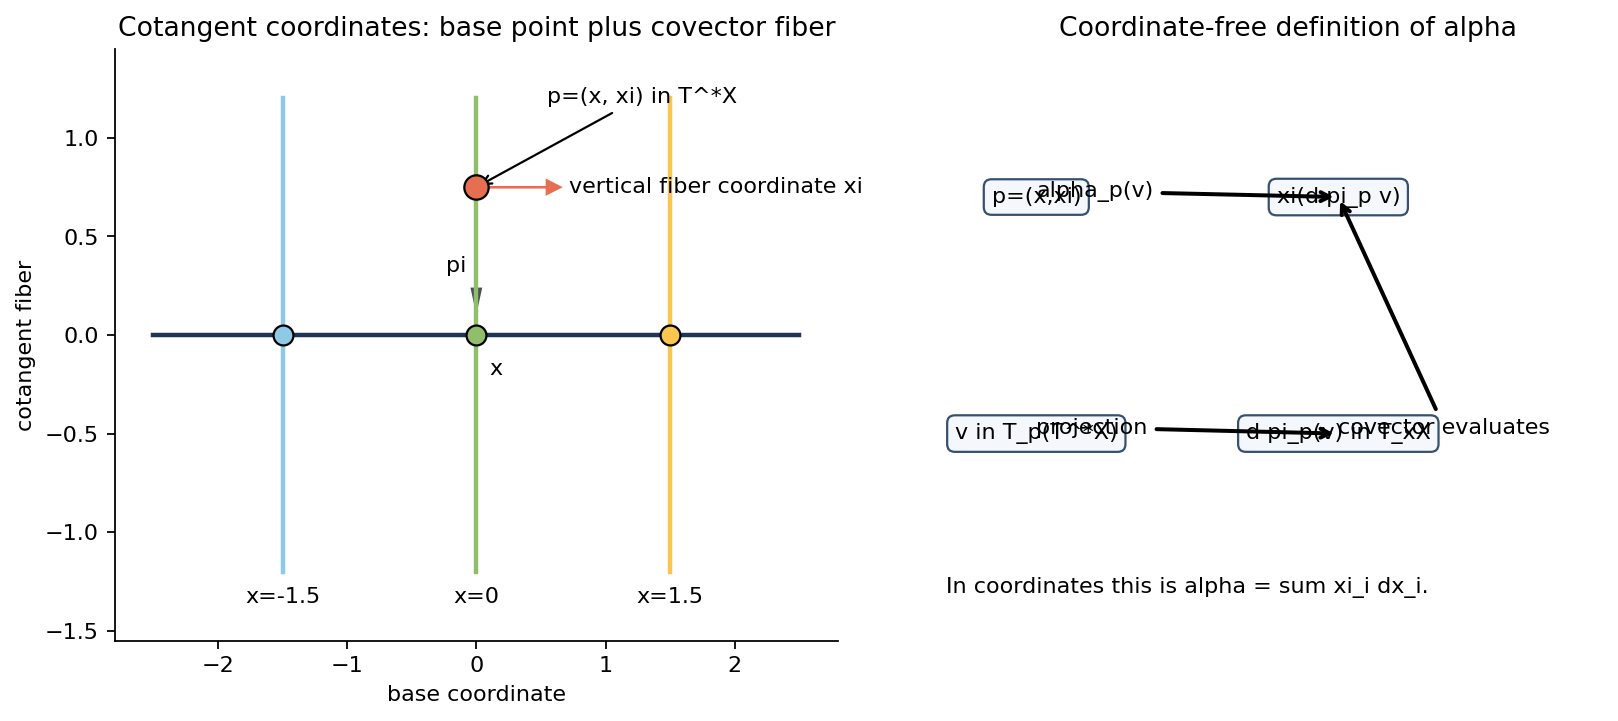

naturality under cotangent lifts -> artifacts\lecture-02\figures\cotangent-lift-naturality-cylinder.png


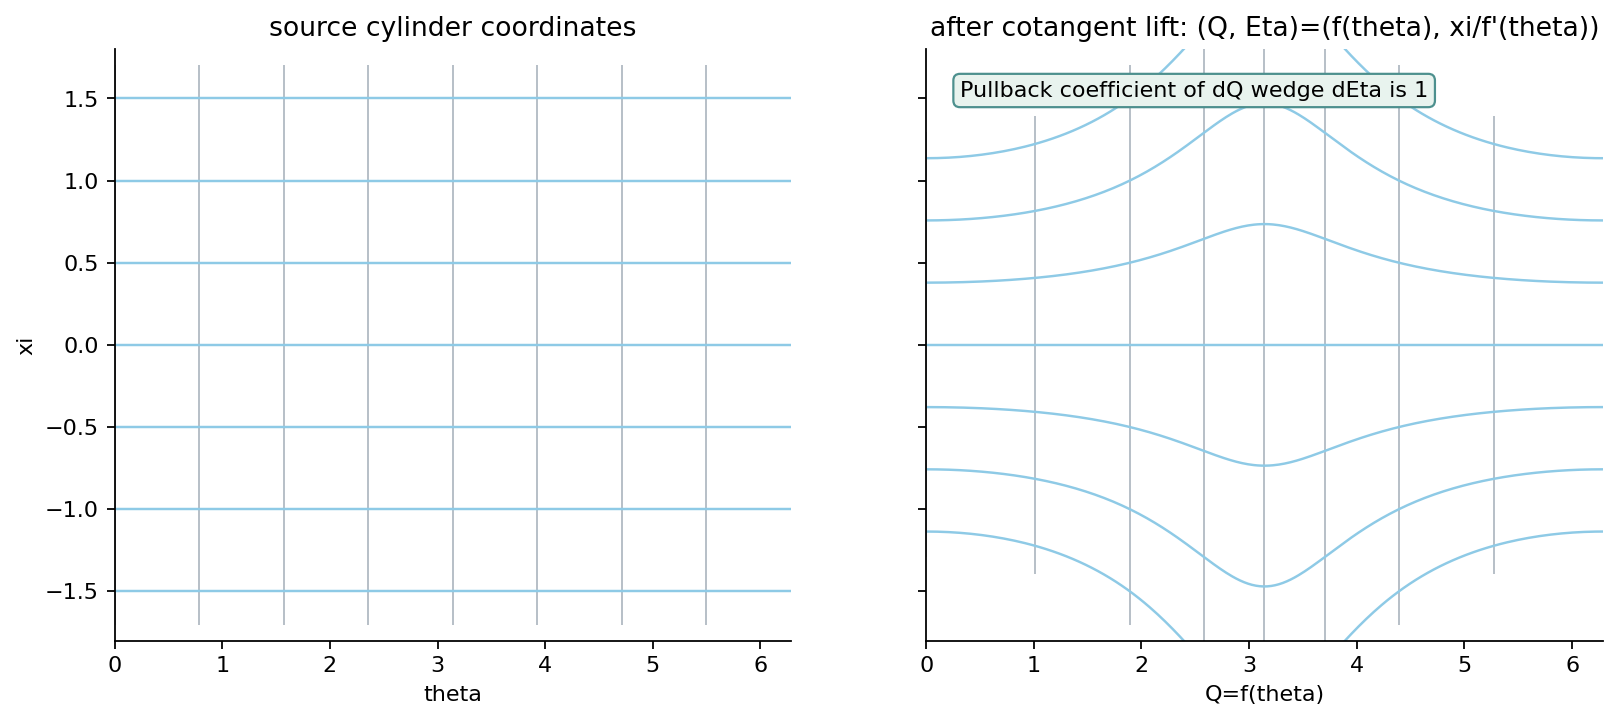

canonical-form proof route -> artifacts\lecture-02\figures\cotangent-canonical-proof-route.png


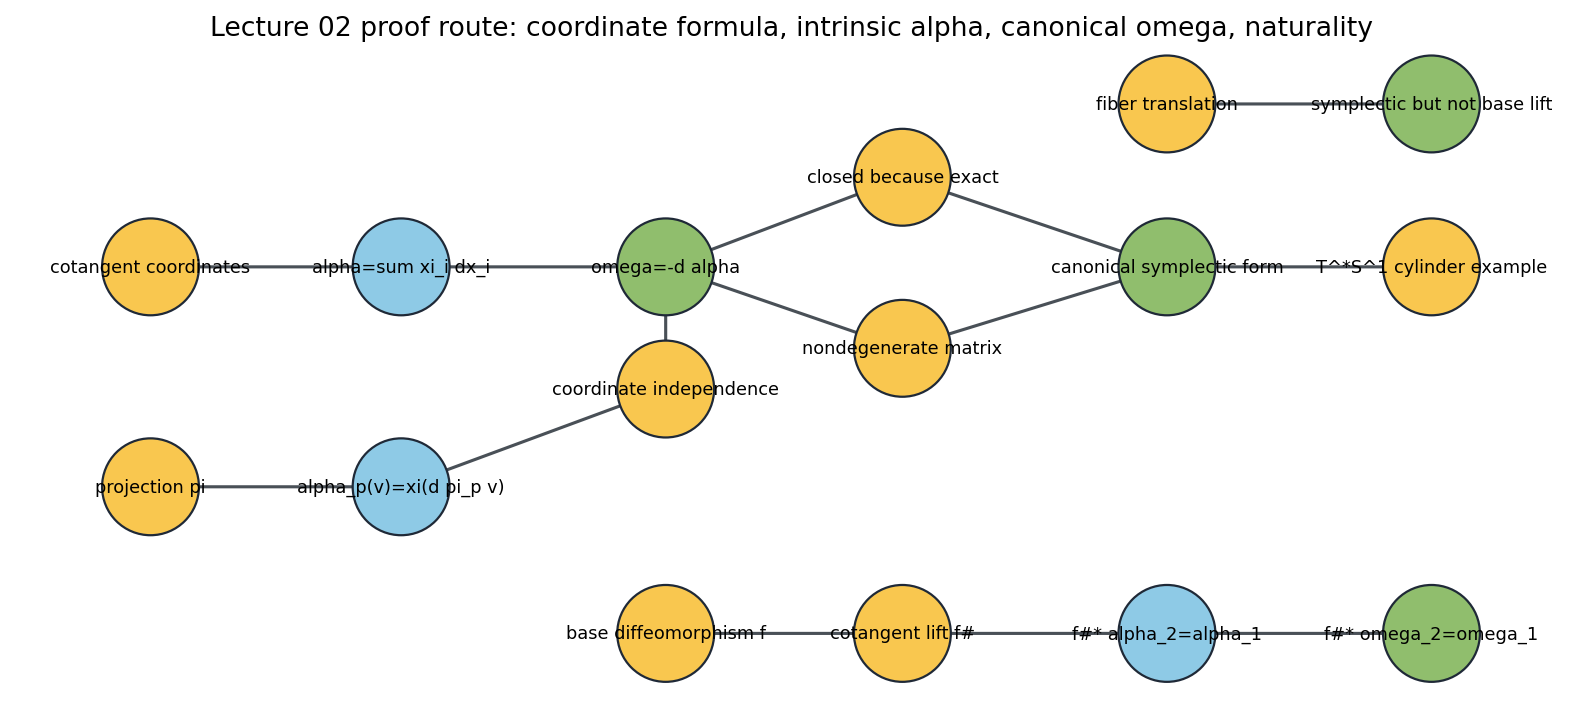

symplectic volume homework ledger -> artifacts\lecture-02\figures\symplectic-volume-wedge-ledger.png


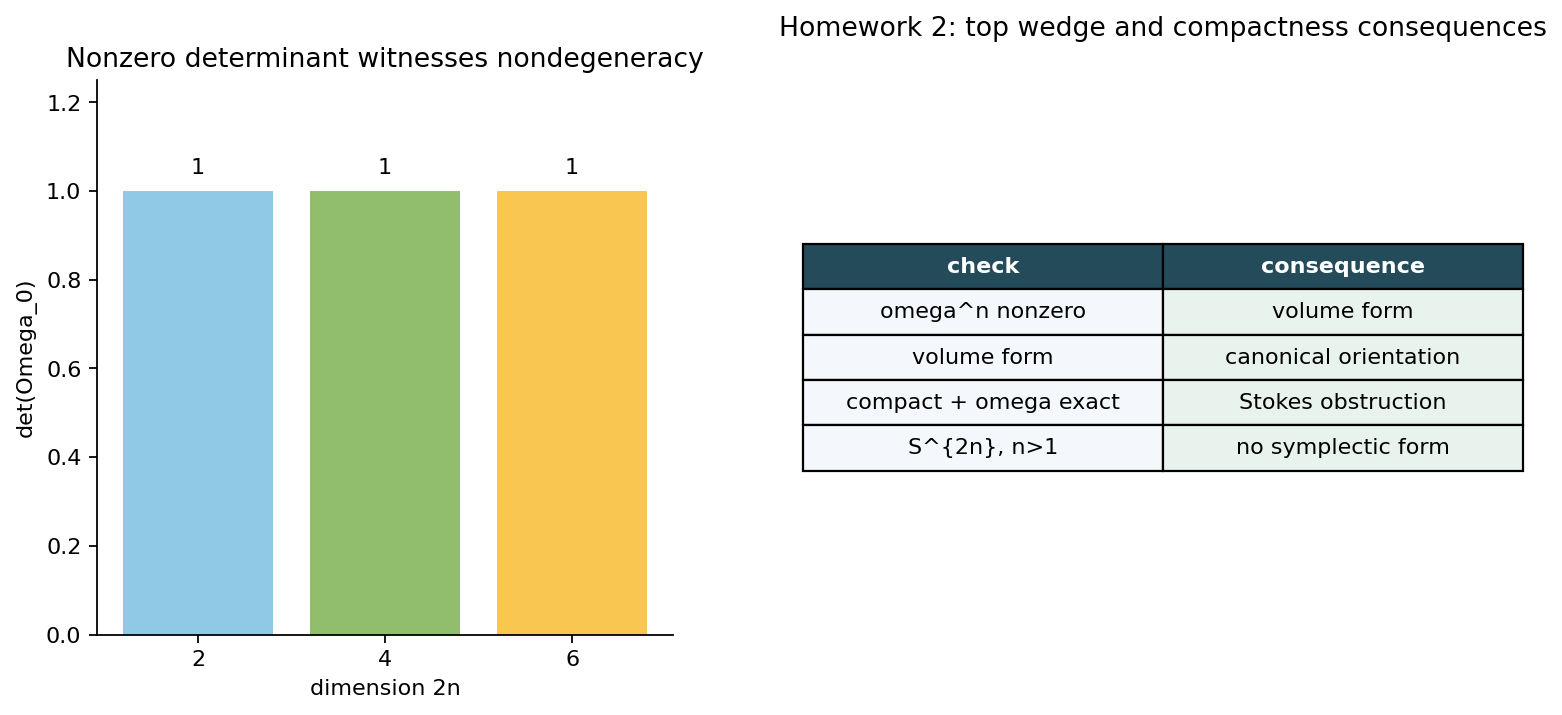

In [8]:
storyboard = read_json(ARTIFACT_ROOT / "checks" / "visual-storyboard.json")
for item in storyboard["visual_sequence"]:
    path = BOOK_ROOT / item["artifact"]
    print(f"{item['concept']} -> {path.relative_to(BOOK_ROOT)}")
    display_artifact(path, width=820)

## Takeaways

- `T^*X` has natural coordinates `(x_i, xi_i)` induced from a chart on `X`, but the tautological form is intrinsic.
- The formula `alpha=sum xi_i dx_i` is the coordinate version of `alpha_p(v)=xi(d pi_p v)`.
- The canonical symplectic form is `omega=-d alpha`, so it is closed automatically and locally equals `sum dx_i wedge dxi_i`.
- Every base diffeomorphism has a cotangent lift, and the exact pullback check proves the lift is a symplectomorphism.
- The symplectic volume homework turns nondegeneracy into topology: `omega^n` orients the manifold, and compact exact symplectic forms are obstructed by Stokes' theorem.

**Exploration prompt.** Change the base map to `Q=theta+a sin(2 theta)` with small `a`. Recompute the lifted fiber coordinate and verify that the pullback coefficient of `dQ wedge dEta` is still one.